# Fantasy F1 — Data & Model Exploration

This notebook loads **sessions.parquet** (pipeline output with fantasy points) and **features.parquet** (engineered features) so you can explore and visualize what the model sees.

**Run the pipeline first** (from project root):
- `PYTHONPATH=. python scripts/run_pipeline.py --mode full`
- `PYTHONPATH=. python scripts/run_features.py`

In [1]:
import sys
from pathlib import Path

# Project root = parent of notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

In [2]:
# Load data (paths relative to project root)
sessions_path = ROOT / "data" / "processed" / "sessions.parquet"
features_path = ROOT / "data" / "processed" / "features.parquet"

sessions = pd.read_parquet(sessions_path)
features = pd.read_parquet(features_path)

print("Sessions:", sessions.shape)
print("Features:", features.shape)

Sessions: (4769, 28)
Features: (4769, 46)


## Sessions (race & qualifying with fantasy points)

In [3]:
sessions.head(10)

,year,round,circuit_id,session_type,driver_code,constructor_id,grid_position,finish_position,status,points_official,...,is_dotd,fastest_pitstop_ms,avg_pitstop_ms,air_temp_c,track_temp_c,humidity_pct,wind_speed_ms,rainfall,fantasy_points_driver,constructor_bonus
0,2020,1,red_bull_ring,qualifying,ALB,red_bull,5.0,5.0,Finished,NaN,...,False,None,None,None,None,None,None,None,-5,-1
1,2020,1,red_bull_ring,qualifying,BOT,mercedes,1.0,1.0,Finished,NaN,...,False,None,None,None,None,None,None,None,-5,-1
2,2020,1,red_bull_ring,qualifying,GAS,racing_bulls,12.0,12.0,Finished,NaN,...,False,None,None,None,None,None,None,None,-5,-1
3,2020,1,red_bull_ring,qualifying,GIO,audi,18.0,18.0,Finished,NaN,...,False,None,None,None,None,None,None,None,-5,-1
4,2020,1,red_bull_ring,qualifying,GRO,haas,15.0,15.0,Finished,NaN,...,False,None,None,None,None,None,None,None,-5,-1
5,2020,1,red_bull_ring,qualifying,HAM,mercedes,2.0,2.0,Finished,NaN,...,False,None,None,None,None,None,None,None,-5,-1
6,2020,1,red_bull_ring,qualifying,KVY,racing_bulls,13.0,13.0,Finished,NaN,...,False,None,None,None,None,None,None,None,-5,-1
7,2020,1,red_bull_ring,qualifying,LAT,williams,20.0,20.0,Finished,NaN,...,False,None,None,None,None,None,None,None,-5,-1
8,2020,1,red_bull_ring,qualifying,LEC,ferrari,7.0,7.0,Finished,NaN,...,False,None,None,None,None,None,None,None,-5,-1
9,2020,1,red_bull_ring,qualifying,MAG,haas,16.0,16.0,Finished,NaN,...,False,None,None,None,None,None,None,None,-5,-1


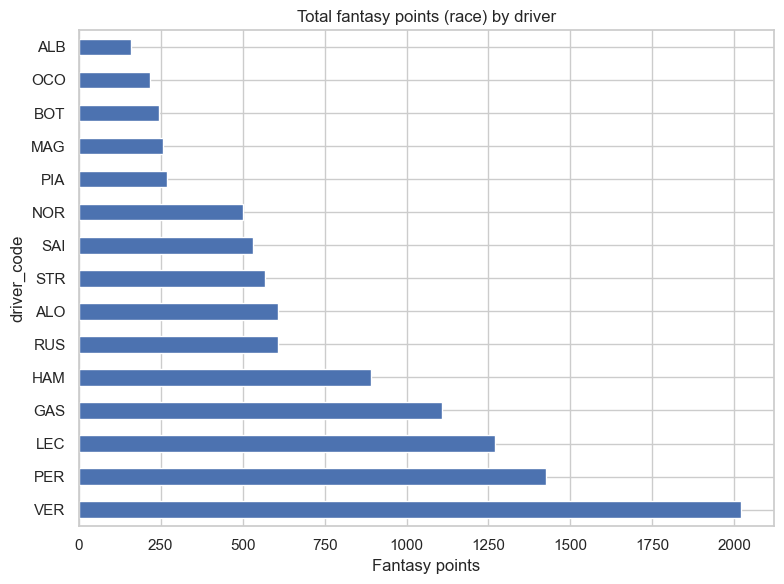

In [4]:
# Fantasy points by driver (race sessions only)
race = sessions[sessions["session_type"] == "race"]
driver_pts = race.groupby("driver_code")["fantasy_points_driver"].sum().sort_values(ascending=False)
driver_pts.head(15).plot(kind="barh", figsize=(8, 6), title="Total fantasy points (race) by driver")
plt.xlabel("Fantasy points")
plt.tight_layout()
plt.show()

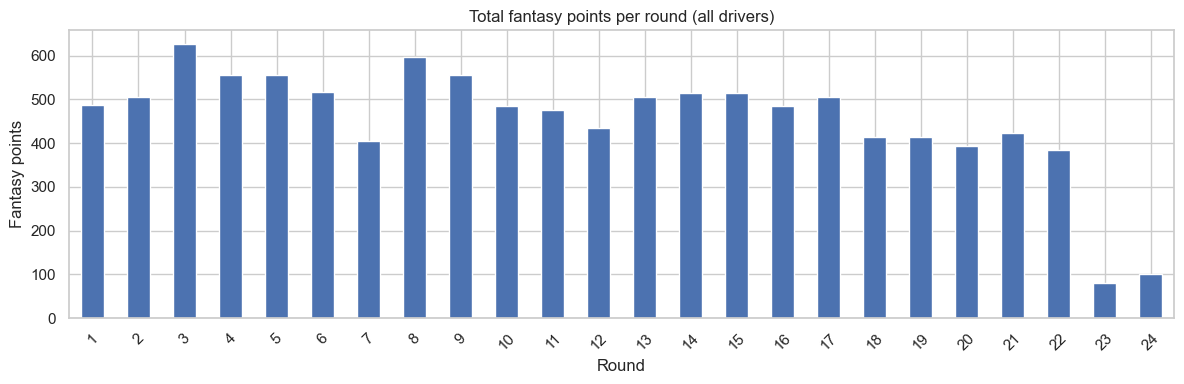

In [5]:
# Fantasy points by round (race only)
pts_by_round = race.groupby("round")["fantasy_points_driver"].sum()
pts_by_round.plot(kind="bar", figsize=(12, 4), title="Total fantasy points per round (all drivers)")
plt.xlabel("Round")
plt.ylabel("Fantasy points")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Features (for modelling)

In [6]:
features.head(10)

,year,round,circuit_id,session_type,driver_code,constructor_id,grid_position,finish_position,status,points_official,...,driver_rolling_pts_3,driver_rolling_pts_5,driver_avg_finish_at_circuit,driver_overtake_rate,driver_dnf_rate,team_development_score,team_regulation_adaptation,team_development_trajectory,team_fastest_pitstop_avg,team_avg_pitstop_avg
0,2020,1,red_bull_ring,qualifying,ALB,red_bull,5.0,5.0,Finished,NaN,...,NaN,NaN,NaN,NaN,NaN,4.0,unknown,stable,None,None
1,2020,1,red_bull_ring,qualifying,BOT,mercedes,1.0,1.0,Finished,NaN,...,NaN,NaN,NaN,NaN,NaN,4.0,unknown,stable,None,None
2,2020,1,red_bull_ring,qualifying,GAS,racing_bulls,12.0,12.0,Finished,NaN,...,NaN,NaN,NaN,NaN,NaN,3.0,unknown,stable,None,None
3,2020,1,red_bull_ring,qualifying,GIO,audi,18.0,18.0,Finished,NaN,...,NaN,NaN,NaN,NaN,NaN,3.0,unknown,stable,None,None
4,2020,1,red_bull_ring,qualifying,GRO,haas,15.0,15.0,Finished,NaN,...,NaN,NaN,NaN,NaN,NaN,2.0,unknown,stable,None,None
5,2020,1,red_bull_ring,qualifying,HAM,mercedes,2.0,2.0,Finished,NaN,...,NaN,NaN,NaN,NaN,NaN,4.0,unknown,stable,None,None
6,2020,1,red_bull_ring,qualifying,KVY,racing_bulls,13.0,13.0,Finished,NaN,...,NaN,NaN,NaN,NaN,NaN,3.0,unknown,stable,None,None
7,2020,1,red_bull_ring,qualifying,LAT,williams,20.0,20.0,Finished,NaN,...,NaN,NaN,NaN,NaN,NaN,3.0,unknown,stable,None,None
8,2020,1,red_bull_ring,qualifying,LEC,ferrari,7.0,7.0,Finished,NaN,...,NaN,NaN,NaN,NaN,NaN,4.0,unknown,stable,None,None
9,2020,1,red_bull_ring,qualifying,MAG,haas,16.0,16.0,Finished,NaN,...,NaN,NaN,NaN,NaN,NaN,2.0,unknown,stable,None,None


In [7]:
# Numeric feature columns (sample)
num_cols = [c for c in features.columns if features[c].dtype in ("float64", "int64")]
num_cols = [c for c in num_cols if c not in ("year", "round", "grid_position", "finish_position")]
if num_cols:
    features[num_cols[:8]].describe()

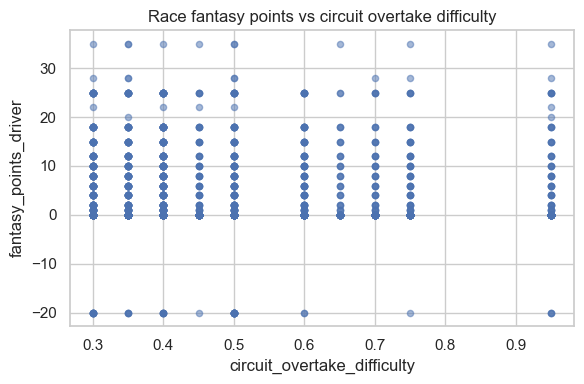

In [8]:
# Driver fantasy points vs a feature (e.g. circuit difficulty) — race rows only
race_feat = features[features["session_type"] == "race"].copy()
if "circuit_overtake_difficulty" in race_feat.columns and "fantasy_points_driver" in race_feat.columns:
    race_feat.plot.scatter(x="circuit_overtake_difficulty", y="fantasy_points_driver", alpha=0.5, figsize=(6, 4))
    plt.title("Race fantasy points vs circuit overtake difficulty")
    plt.tight_layout()
    plt.show()

## Walk-Forward Backtest Diagnostics

This section reads the saved walk-forward outputs from:
- `data/processed/models/backtest/walk_forward_2025_predictions.parquet`
- `data/processed/models/backtest/walk_forward_2025_metrics.json`

and visualizes per-round error plus the most over/under-predicted drivers.

In [9]:
from pathlib import Path
import json

wf_pred_path = ROOT / "data" / "processed" / "models" / "backtest" / "walk_forward_2025_predictions.parquet"
wf_metrics_path = ROOT / "data" / "processed" / "models" / "backtest" / "walk_forward_2025_metrics.json"

if wf_pred_path.exists():
    wf_preds = pd.read_parquet(wf_pred_path)
    print("Walk-forward predictions:", wf_preds.shape)
else:
    wf_preds = pd.DataFrame()
    print("Walk-forward predictions file not found:", wf_pred_path)

if wf_metrics_path.exists():
    wf_metrics = json.loads(wf_metrics_path.read_text())
    print("Walk-forward overall metrics:", wf_metrics.get("overall", {}))
else:
    wf_metrics = {}
    print("Walk-forward metrics file not found:", wf_metrics_path)

wf_preds.head(10) if not wf_preds.empty else wf_preds

Walk-forward predictions: (159, 17)
Walk-forward overall metrics: {'mae': 7.775768332070704, 'rmse': 11.563780638229066, 'n': 159}


,year,round,driver_code,constructor_id,y_true,y_pred,abs_error,sq_error,y_pred_prev_driver,y_pred_roll3_driver,y_pred_constructor_mean,abs_error_prev_driver,sq_error_prev_driver,abs_error_roll3_driver,sq_error_roll3_driver,abs_error_constructor_mean,sq_error_constructor_mean
0,2025,1,ALB,mercedes,10,1.356127,8.643873,74.716545,0.000000,0.000000,7.641509,10.000000,100.000000,10.000000,100.000000,2.358491,5.562478
1,2025,1,ALO,mercedes,-20,2.132312,22.132312,489.839253,0.000000,1.333333,7.641509,20.000000,400.000000,21.333333,455.111111,27.641509,764.053044
2,2025,1,ANT,mercedes,12,1.102020,10.897980,118.765973,4.962648,4.962648,7.641509,7.037352,49.524327,7.037352,49.524327,4.358491,18.996440
3,2025,1,BEA,ferrari,0,1.102020,1.102020,1.214448,4.962648,4.962648,8.289100,4.962648,24.627873,4.962648,24.627873,8.289100,68.709171
4,2025,1,BOR,ferrari,-20,1.102020,21.102020,445.295239,4.962648,4.962648,8.289100,24.962648,623.133783,24.962648,623.133783,28.289100,800.273152
5,2025,1,DOO,alpine,-20,0.301413,20.301413,412.147389,4.962648,4.962648,4.561798,24.962648,623.133783,24.962648,623.133783,24.561798,603.281909
6,2025,1,GAS,alpine,0,-2.701447,2.701447,7.297814,0.000000,0.666667,4.561798,0.000000,0.000000,0.666667,0.444444,4.561798,20.809999
7,2025,1,HAD,racing_bulls,-20,0.301413,20.301413,412.147389,4.962648,4.962648,5.113744,24.962648,623.133783,24.962648,623.133783,25.113744,630.700142
8,2025,1,HAM,ferrari,1,20.598060,19.598060,384.083944,18.000000,18.000000,8.289100,17.000000,289.000000,17.000000,289.000000,7.289100,53.130972
9,2025,1,HUL,ferrari,6,1.154924,4.845076,23.474760,0.000000,0.000000,8.289100,6.000000,36.000000,6.000000,36.000000,2.289100,5.239977


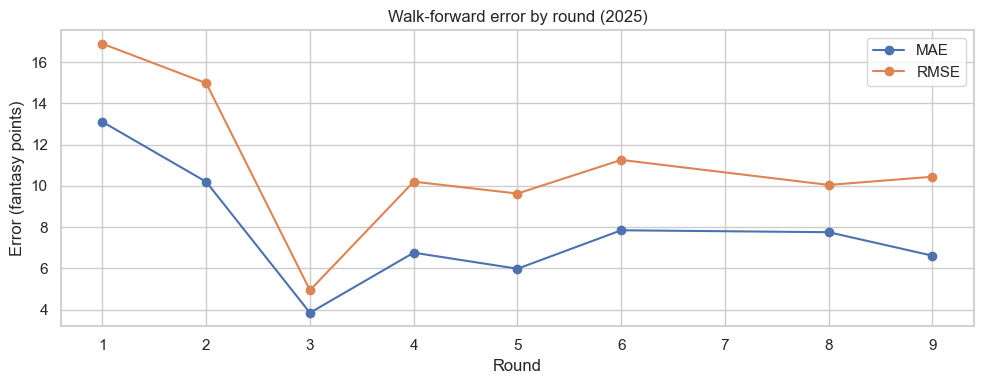

In [10]:
if not wf_preds.empty:
    round_err = (
        wf_preds.groupby("round")
        .agg(
            mae=("abs_error", "mean"),
            rmse=("sq_error", lambda s: float((s.mean()) ** 0.5)),
            n=("driver_code", "count"),
        )
        .reset_index()
        .sort_values("round")
    )

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(round_err["round"], round_err["mae"], marker="o", label="MAE")
    ax.plot(round_err["round"], round_err["rmse"], marker="o", label="RMSE")
    ax.set_title("Walk-forward error by round (2025)")
    ax.set_xlabel("Round")
    ax.set_ylabel("Error (fantasy points)")
    ax.legend()
    plt.tight_layout()
    plt.show()

    round_err
else:
    print("No walk-forward predictions available yet. Run: PYTHONPATH=. python scripts/train_model.py")

Top over-predicted drivers (predicted too high):


,driver_code,mean_error,mae,n
17,SAI,8.511789,11.327716,8
1,ALO,8.319491,9.942442,8
4,BOR,7.157237,7.586314,8
6,DOO,7.109735,8.074066,6
11,LAW,5.602769,7.282112,8
7,GAS,5.207945,11.321282,8
9,HAM,5.024002,9.036376,8
3,BEA,4.471240,4.510377,8
19,TSU,3.135693,5.399747,8
10,HUL,2.945173,6.197979,8


Top under-predicted drivers (predicted too low):


,driver_code,mean_error,mae,n
13,NOR,-10.812522,11.404316,8
15,PIA,-9.883956,13.443849,8
5,COL,0.671646,0.671646,2
18,STR,0.685509,2.834510,7
14,OCO,0.841908,3.488966,8
12,LEC,0.916599,11.341336,8
16,RUS,1.113522,6.987885,8
8,HAD,1.799691,4.775178,8
2,ANT,1.957571,9.051632,8
20,VER,2.695589,6.177351,8


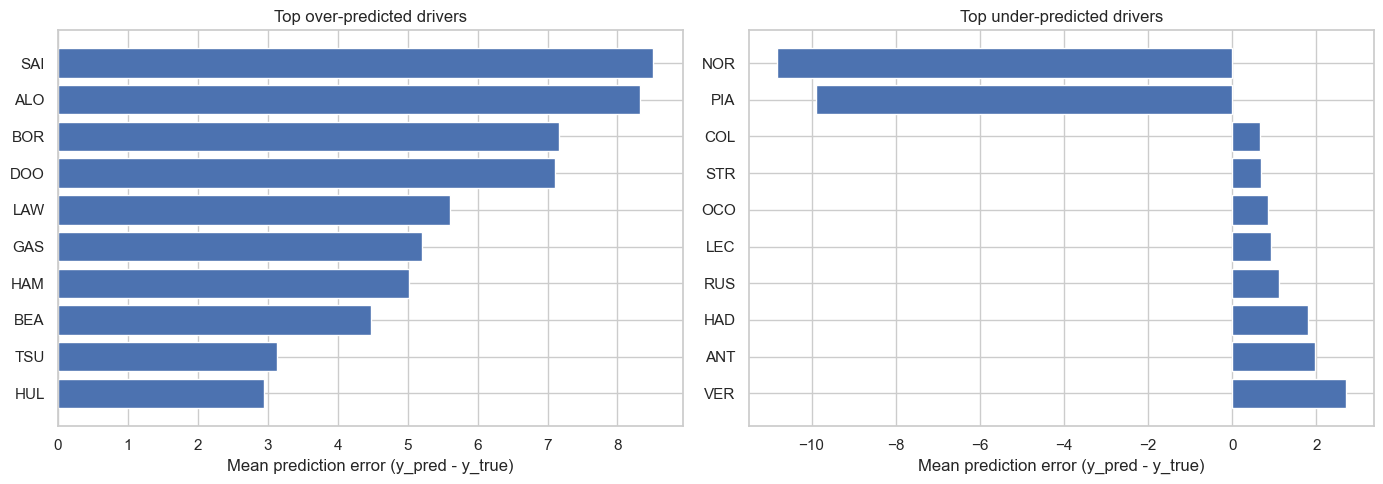

In [11]:
if not wf_preds.empty:
    driver_err = (
        wf_preds.assign(error=lambda d: d["y_pred"] - d["y_true"])
        .groupby("driver_code")
        .agg(mean_error=("error", "mean"), mae=("abs_error", "mean"), n=("driver_code", "count"))
        .reset_index()
    )

    over_pred = driver_err.sort_values("mean_error", ascending=False).head(10)
    under_pred = driver_err.sort_values("mean_error", ascending=True).head(10)

    print("Top over-predicted drivers (predicted too high):")
    display(over_pred)
    print("Top under-predicted drivers (predicted too low):")
    display(under_pred)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].barh(over_pred["driver_code"], over_pred["mean_error"])
    axes[0].set_title("Top over-predicted drivers")
    axes[0].set_xlabel("Mean prediction error (y_pred - y_true)")
    axes[0].invert_yaxis()

    axes[1].barh(under_pred["driver_code"], under_pred["mean_error"])
    axes[1].set_title("Top under-predicted drivers")
    axes[1].set_xlabel("Mean prediction error (y_pred - y_true)")
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()
else:
    print("No walk-forward predictions available yet.")

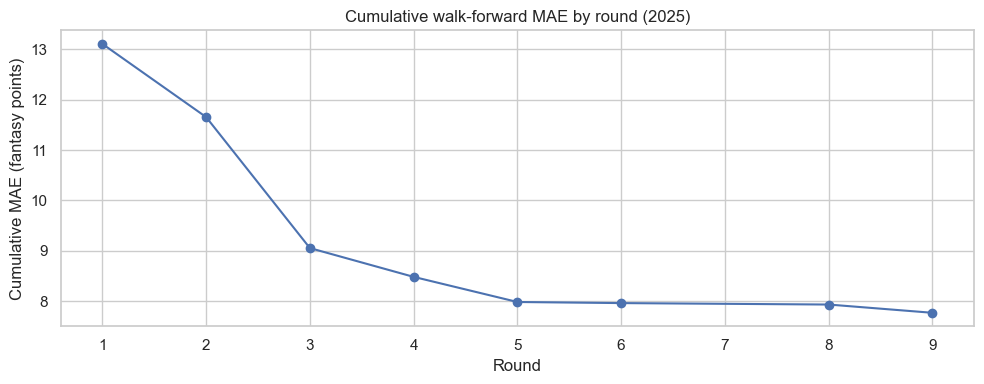

In [12]:
# Cumulative walk-forward MAE over rounds
if not wf_preds.empty:
    round_err = (
        wf_preds.groupby("round")
        .agg(mae=("abs_error", "mean"), n=("driver_code", "count"))
        .reset_index()
        .sort_values("round")
    )
    round_err["cum_mae"] = round_err["mae"].expanding().mean()

    plt.figure(figsize=(10, 4))
    plt.plot(round_err["round"], round_err["cum_mae"], marker="o")
    plt.title("Cumulative walk-forward MAE by round (2025)")
    plt.xlabel("Round")
    plt.ylabel("Cumulative MAE (fantasy points)")
    plt.tight_layout()
    plt.show()

    round_err[["round", "mae", "cum_mae", "n"]]
else:
    print("No walk-forward predictions available yet.")

,model,mae,rmse
0,Model (configured),7.775768,11.563781
2,roll3_driver,8.539098,11.553897
1,prev_driver,9.356708,13.122756
3,constructor_mean,9.755180,13.019424


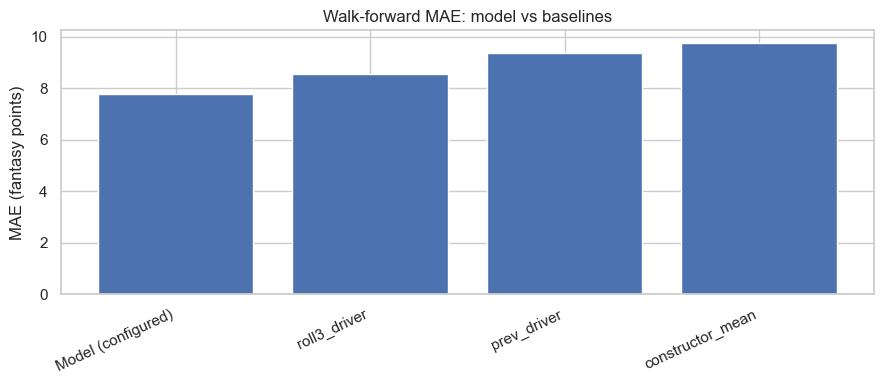

In [13]:
# Model vs baseline benchmark comparison (walk-forward overall)
if wf_metrics and wf_metrics.get("benchmark_overall"):
    bench_rows = [
        {
            "model": "Model (configured)",
            "mae": wf_metrics.get("overall", {}).get("mae"),
            "rmse": wf_metrics.get("overall", {}).get("rmse"),
        }
    ]
    for name, m in wf_metrics["benchmark_overall"].items():
        bench_rows.append({"model": name, "mae": m.get("mae"), "rmse": m.get("rmse")})

    bench_df = pd.DataFrame(bench_rows).sort_values("mae")
    display(bench_df)

    plt.figure(figsize=(9, 4))
    plt.bar(bench_df["model"], bench_df["mae"])
    plt.title("Walk-forward MAE: model vs baselines")
    plt.ylabel("MAE (fantasy points)")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No benchmark metrics found. Re-run: PYTHONPATH=. python scripts/train_model.py")